# This notebook is called ```PeriodicPaymentInvestment.ipynb```

Launch the SageMath app by clicking on it.  
Alternatively, go to the directory contaning this notebook and launch SageMath from the command line with

```sage --notebook```

Then open this notebook file.  Make sure your Jupyter notebook has SageMath as the kernel: 

```Kernel ➤ Change Kernel ➤ Select Kernel = SageMath 10.2```

<span style="color:red;">I urge you</span> to do <i>Kernel->Restart Kernel and Clear All Outputs </i>, followed by <i>Kernel->Restart Kernel and Run All Cells</i>

# Compute the equivalent interest for the year if we make the same contribution periodically every paycheck.
## Let's assume compounding is every pay period.  Usually banks do monthly or daily compounding.  Thus the compound interest will be a little more.
### Compound interest formula for n periods is $(1 + \frac{i}{n})^n$  See  https://www.investopedia.com/terms/a/apy.asp
If you deposited $100$ for one year at 5% interest and your deposit was compounded quarterly, at the end of the year you would have $105.09$. If you had been paid simple interest, you would have had $105$.
The APY would be $(1+4.05​)4−1=.05095=5.095%$.

In [1]:
def compound_interest( i, n ):
    return (1 + i / n) ^ n

In [2]:
compound_interest( i, 1 )-1

I

In [3]:
print( f"{100.0 * (compound_interest(0.05, 4)-1):8.3f} %")

   5.095 %


In [4]:
def equivalent_interest( i, num_pay_periods=26, yearly_contribution=1000, **kwargs ):
    """What is the interest for an entire year if we periodically contribute the same amount"""
    debug = kwargs.get('debug')
    
    # Define symbolic variables so we can have infinite precision.
    var('k')
    var('gain')
    var('contribution_per_pay_period')
    var('contribution_with_compounding')
    var('yearly_compounded_salary')
    var('yearly_equivalent_interest')
    
    # Use fractions instead of percentages in calculations.
    i /= 100
    
    # Divide up yearly salary into equal paychecks.
    contribution_per_pay_period = yearly_contribution/num_pay_periods
    
    # Apply compound interest to each paycheck in kth pay period to the end of the year.  Then sum them up.
    yearly_compounded_salary = 0
    for k in [1..num_pay_periods]:
        # Let's assume compounding is every pay period.  Usually banks do monthly or daily compounding.  So not exact, but close enough.
        contribution_with_compounding = compound_interest(i,k) * contribution_per_pay_period
        equivalent_interest = (contribution_with_compounding - contribution_per_pay_period)/contribution_per_pay_period
        if debug:
            print( f"k = {k:2d} interest = {100.0*float(i):8.1f}% contribution per pay period = {float(contribution_per_pay_period):8.2f} with compounding = {float(contribution_with_compounding):8.2f} equivalent interest = {100.0*float(equivalent_interest):8.5f}%" )
        yearly_compounded_salary += contribution_with_compounding

    # The equivalent simple interest for the year.
    yearly_equivalent_interest = (yearly_compounded_salary - yearly_contribution)/yearly_contribution

    if debug:
        print(f"\ninterest rate                        = {100.0*float(i):8.1f}%")
        print(f"contribution per pay period          = {float(contribution_per_pay_period):8.2f}\n")
        print(f"yearly contribution                  = {float(yearly_contribution):8.2f}")
        print(f"yearly contribution with compounding = {float(yearly_compounded_salary):8.2f}")
        print(f"Yearly interest rate                 = {100.0*float(i):8.2f} %")
        print(f"Yearly equivalent interest           = {100.0 * float(yearly_equivalent_interest):8.2f} %")
    
    return 100 * float(yearly_equivalent_interest)

In [5]:
equivalent_interest( 10 )

10.437408355371522

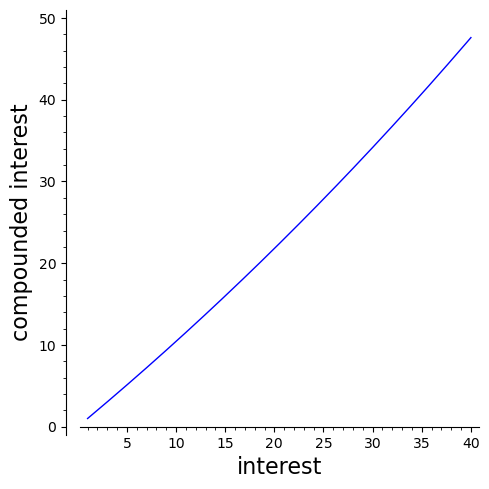

In [6]:
# axes='False' centers the labels along the axes. See https://ask.sagemath.org/question/9235/2d-plot-axes-labels/
plot(equivalent_interest,(1,40),xmin=0,xmax=40,ymin=0, ymax=50,axes_labels=['interest','compounded interest'],axes='False',figsize=(5,5))